In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from transformers import AutoModelForSequenceClassification, AutoTokenizer

sys.path.append(str(Path.cwd().parent))

from src.dataset import ID2LABEL, LABEL2ID, build_dataset_dict
from src.train import get_device

ROOT = Path.cwd().parent
device = get_device()
print(f"Using device: {device}")
print(f"Labels: {ID2LABEL}")

Using device: xpu
Labels: {0: 'negative', 1: 'neutral', 2: 'positive'}


In [2]:
model_dir = ROOT / "outputs" / "best_model"
tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
model = AutoModelForSequenceClassification.from_pretrained(str(model_dir)).to(device)
model.eval()
print(f"Loaded model from {model_dir}")

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loaded model from /home/seno/Documents/workspace/dl-portfolio/08-indobert-finetuning/outputs/best_model


In [3]:
raw = build_dataset_dict(str(ROOT / "data"))
test_ds = raw["test"]
print(test_ds)
print(f"Test split: {len(test_ds)} samples")

Dataset({
    features: ['text', 'label'],
    num_rows: 500
})
Test split: 500 samples


In [4]:
def predict_batch(model, tokenizer, texts, batch_size=32, device=device):
    preds = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            enc = tokenizer(batch, truncation=True, padding=True, max_length=128, return_tensors="pt")
            enc = {k: v.to(device) for k, v in enc.items()}
            logits = model(**enc).logits
            preds.extend(logits.argmax(dim=1).cpu().tolist())
    return np.array(preds)


test_texts = test_ds["text"]
test_labels = np.array(test_ds["label"])
test_preds = predict_batch(model, tokenizer, test_texts)
print(classification_report(test_labels, test_preds, target_names=[ID2LABEL[i] for i in range(len(LABEL2ID))]))

              precision    recall  f1-score   support

    negative       0.94      1.00      0.97       204
     neutral       0.97      0.69      0.81        88
    positive       0.93      0.98      0.95       208

    accuracy                           0.94       500
   macro avg       0.95      0.89      0.91       500
weighted avg       0.94      0.94      0.93       500



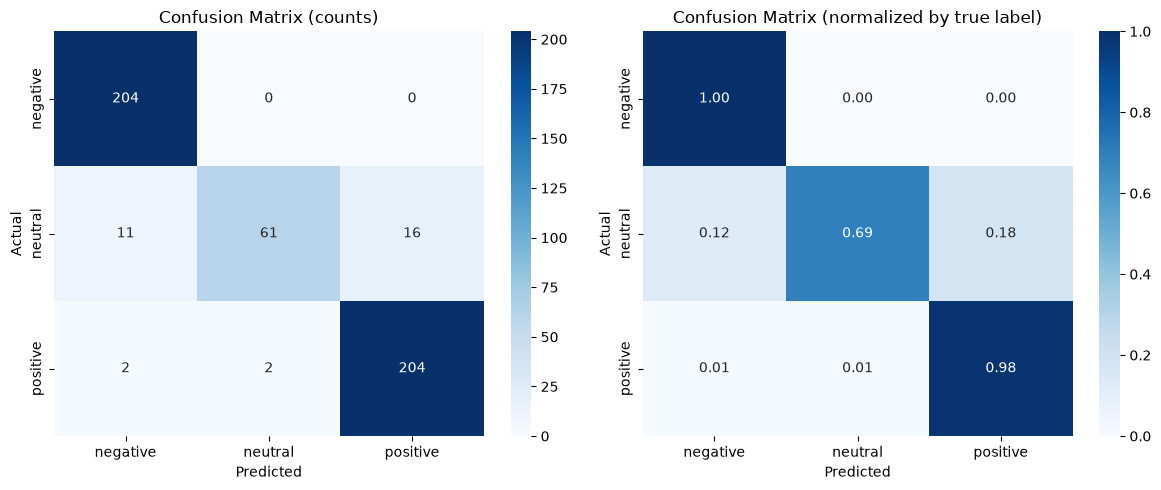

In [5]:
labels_order = sorted(LABEL2ID.values())
label_names = [ID2LABEL[i] for i in labels_order]

cm = confusion_matrix(test_labels, test_preds, labels=labels_order)
cm_norm = confusion_matrix(test_labels, test_preds, labels=labels_order, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names,
            yticklabels=label_names, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=label_names,
            yticklabels=label_names, ax=axes[1])
axes[1].set_title("Confusion Matrix (normalized by true label)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(ROOT / "outputs" / "confusion_matrix.png", dpi=150)
plt.show()

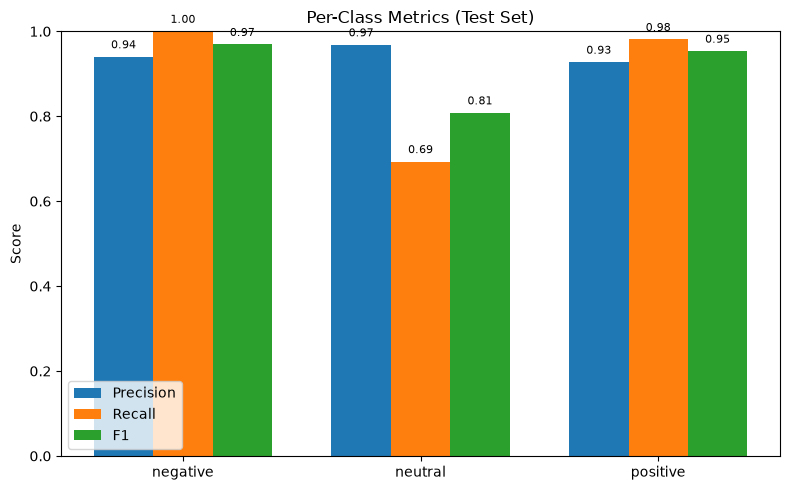

In [6]:
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, test_preds, labels=labels_order, zero_division=0
)

x = np.arange(len(label_names))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width, precision, width, label="Precision")
ax.bar(x, recall, width, label="Recall")
ax.bar(x + width, f1, width, label="F1")

ax.set_xticks(x)
ax.set_xticklabels(label_names)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Per-Class Metrics (Test Set)")
ax.legend()

for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax.text(i - width, p + 0.02, f"{p:.2f}", ha="center", fontsize=8)
    ax.text(i, r + 0.02, f"{r:.2f}", ha="center", fontsize=8)
    ax.text(i + width, f + 0.02, f"{f:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / "outputs" / "per_class_metrics.png", dpi=150)
plt.show()

In [7]:
import pandas as pd

results_df = pd.DataFrame({
    "text": test_texts,
    "actual": [ID2LABEL[l] for l in test_labels],
    "predicted": [ID2LABEL[p] for p in test_preds],
})
misclassified = results_df[results_df["actual"] != results_df["predicted"]]

neutral_errors = misclassified[
    (misclassified["actual"] == "neutral") | (misclassified["predicted"] == "neutral")
]
print(f"Total misclassified: {len(misclassified)} / {len(results_df)}")
print(f"Neutral-related errors: {len(neutral_errors)}")
neutral_errors.head(15)

Total misclassified: 31 / 500
Neutral-related errors: 29


,text,actual,predicted
251,daftar harga dispenser 2018 terbaik yang ada d...,neutral,positive
257,"kalau tidak suka gaperlu didukung mas , dukung...",neutral,positive
261,"maaf ini oot . yang hape nya xiaomi , bisa ban...",neutral,negative
262,di indonesia pilihan brand smartphone kan meli...,neutral,positive
271,"di pesona festival pasar terapung , ada juga p...",neutral,positive
294,sebuah musibah baru saja menimpa kampung adat ...,neutral,negative
433,kalau mau jalan-jalan melihat pulau paling can...,positive,neutral
450,"kalau mau indonesia maju , pemimpin itu harus ...",neutral,positive
451,di indonesia lagi banyak bencana .,neutral,negative
453,gojek fitur nya makin banyak .,neutral,positive
